# 260513 LightGBM SHAP 분석

입력 CSV는 `park.ingyeom/data/(광일)Membership_v2_with_derived_features.csv`를 기준으로 찾습니다.  
출력물은 `park.ingyeom/reports/shap_outputs_260513/` 아래에 저장됩니다.


In [9]:
# =============================================================================
# 1. 라이브러리 로드
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, brier_score_loss

from lightgbm import LGBMClassifier

import shap

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [10]:
# =============================================================================
# 2. 설정 및 경로 탐색
# =============================================================================

TARGET = "is_repurchase"
DATA_FILENAME = "(광일)Membership_v2_with_derived_features.csv"

RANDOM_STATE = 42
TEST_SIZE = 0.2
MAX_SHAP_SAMPLE = 3000

OUTPUT_FOLDER_NAME = "shap_outputs_260513"


def find_project_dir(data_filename: str) -> Path:
    # 현재 실행 위치가 repo root / park.ingyeom / notebook 어디든 데이터 파일을 찾도록 처리.
    cwd = Path.cwd().resolve()

    candidates = [
        cwd,
        cwd.parent,
        cwd.parent.parent,
        cwd / "park.ingyeom",
        cwd.parent / "park.ingyeom",
        cwd.parent.parent / "park.ingyeom",
    ]

    seen = set()
    unique_candidates = []
    for p in candidates:
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for base in unique_candidates:
        if (base / "data" / data_filename).exists():
            return base

    checked = "".join(str(base / "data" / data_filename) for base in unique_candidates)
    raise FileNotFoundError(
        "입력 CSV를 찾지 못했습니다. 아래 후보 경로를 확인했습니다."
        f"{checked}"
    )


PROJECT_DIR = find_project_dir(DATA_FILENAME)
DATA_DIR = PROJECT_DIR / "data"
REPORTS_DIR = PROJECT_DIR / "reports"
OUTPUT_DIR = REPORTS_DIR / OUTPUT_FOLDER_NAME

DATA_PATH = DATA_DIR / DATA_FILENAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("경로 확인")
print("=" * 80)
print(f"cwd         : {Path.cwd().resolve()}")
print(f"PROJECT_DIR : {PROJECT_DIR}")
print(f"DATA_PATH   : {DATA_PATH}")
print(f"OUTPUT_DIR  : {OUTPUT_DIR}")


경로 확인
cwd         : C:\Code\ott-churn-prediction\park.ingyeom\notebook
PROJECT_DIR : C:\Code\ott-churn-prediction\park.ingyeom
DATA_PATH   : C:\Code\ott-churn-prediction\park.ingyeom\data\(광일)Membership_v2_with_derived_features.csv
OUTPUT_DIR  : C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513


In [11]:
# =============================================================================
# 3. 컬럼 제거 정책
# =============================================================================

DROP_COLS = [
    # 식별자
    "USER_KEY",
    "USER_NUM",
    "membership_row_id",

    # 원본 범주형 또는 파생변수로 대체한 컬럼
    "product_code",
    "billing_method",
    "payment_device",
    "gender",

    # 날짜
    "reg_date",
    "end_date",

    # 기존 논의 기준 제거 대상
    "price",
    "max_screen",
    "max_screen_num",
    "MAX_SCREEN_NUM",
]

# TARGET인 is_repurchase는 c == TARGET 조건으로 보호함.
LEAKAGE_KEYWORDS = [
    "repurchase",
    "next_payment",
    "next_reg",
    "next_end",
    "future",
    "label",
]


In [12]:
# =============================================================================
# 4. 데이터 로드
# =============================================================================

df_raw = pd.read_csv(DATA_PATH)

if TARGET not in df_raw.columns:
    raise ValueError(f"타깃 컬럼이 없습니다: {TARGET}")

print("=" * 80)
print("원본 데이터 확인")
print("=" * 80)
print(f"df_raw shape : {df_raw.shape}")
print(f"target       : {TARGET}")
print(f"target dist  : {dict(df_raw[TARGET].value_counts(dropna=False).sort_index())}")
print(f"missing cells: {int(df_raw.isna().sum().sum())}")

df_raw.head()


원본 데이터 확인
df_raw shape : (23343, 91)
target       : is_repurchase
target dist  : {0: 6641, 1: 16702}
missing cells: 0


,USER_KEY,product_code,price,billing_method,max_screen,is_promotion,is_churn_prevented,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,is_repurchase,is_standard,is_premium,age_group,is_female,is_male,reg_is_weekend,reg_hour_morning,reg_hour_afternoon,reg_hour_evening,reg_hour_night,payment_is_mobile,payment_is_pc,payment_is_android,payment_is_ios,total_watch_count,unique_movie,watch_days,active_ratio,total_watch_time(min),watch_per_day,avg_watch_time(min),median_watch_time(min),std_watch_time(min),avg_daily_watch_time(min),max_watch_time(min),max_daily_watch_time(min),max_daily_sessions,recency,avg_gap_between_watch_days,avg_gap_w1_watch_days,avg_gap_w2_watch_days,avg_gap_w3_watch_days,max_inactive_gap_days,avg_rewatch_ratio,weekend_watch_ratio,watch_ratio_under_1m,watch_ratio_under_5m,is_cold_start_3d,is_cold_start_7d,movie_per_active_day,max_day_share,day_count_over_3times,watch_time(min)_w1,watch_time(min)_w2,watch_time(min)_w3,watch_session_w1,watch_session_w2,watch_session_w3,retention_w2_ratio,retention_w3_ratio,diff_between_w2_w1,diff_between_w3_w1,diff_between_w3_w2,is_w1_over_50pct,is_w2_over_50pct,is_w3_over_50pct,is_only_w1,is_only_w2,is_only_w3,new_movie_in_90d_ratio,new_movie_in_180d_ratio,new_movie_in_365d_ratio,old_movie_ratio(5y),avg_ott_release_year,genre_diversity_count,action_adventure_ratio,family_animation_ratio,drama_ratio,thriller_crime_ratio,sf_fantasy_ratio,comedy_ratio,romance_ratio,horror_ratio,documentary_ratio,historical_war_ratio,other_ratio
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4.0,1,0,pc,1,F,20.0,2021-03-14,20,2021-04-14,1,0,1,20,1,0,1,0,0,1,0,0,1,0,0,13,10,9,0.428571,518,1.444444,39.846154,13.0,57.936526,57.555556,200,201,2,4,2.00,3.0,1.0,0.0,5,0.230769,0.153846,0.307692,0.384615,1,1,1.111111,0.388031,0,191,313,14,3,8,2,1.635417,0.047771,122,-177,-299,0,1,0,0,0,0,0.230769,0.230769,0.384615,0.0,2019.405405,6,0.22973,0.003861,0.389961,0.361004,0.000000,0.000000,0.013514,0.000000,0.000000,0.0,0.001931
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.0,190,1.0,1,1,pc,1,F,25.0,2021-03-09,14,2021-04-09,0,0,0,20,1,0,0,0,1,0,0,0,1,0,0,3,3,2,0.095238,4,1.500000,1.333333,1.0,0.577350,2.000000,2,3,2,13,1.00,0.0,0.0,0.0,1,0.000000,0.000000,0.666667,1.000000,0,1,1.500000,0.750000,0,3,1,0,2,1,0,0.500000,0.500000,-2,-3,-1,1,0,0,0,0,0,0.333333,0.333333,0.333333,0.0,2019.250000,2,0.75000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2,01b16f9f7ff29b48b1ee0d1a89d1eb9662474e5eedb8c2...,pk_1488,100.0,180,2.0,1,0,android,1,F,20.0,2021-03-09,2,2021-04-09,0,1,0,20,1,0,0,0,0,0,1,0,0,1,0,2,2,1,0.047619,129,2.000000,64.500000,64.5,89.802561,129.000000,128,129,2,10,0.00,0.0,0.0,0.0,0,0.000000,0.000000,0.500000,0.500000,0,0,2.000000,1.000000,0,0,129,0,0,2,0,130.000000,0.007692,129,0,-129,0,1,0,0,1,0,0.500000,0.500000,0.500000,0.0,2018.023256,2,0.00000,0.000000,0.000000,0.992248,0.000000,0.007752,0.000000,0.000000,0.000000,0.0,0.000000
3,534bc7b6b1ce05de6523f79872108d8dccc1dab38e2c1f...,pk_2025,7900.0,151,1.0,0,0,android,0,N,40.0,2021-03-03,19,2021-04-03,1,0,0,40,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0.000000,0,0.000000,0.000000,0.0,0.000000,0.000000,0,0,0,21,0.00,0.0,0.0,0.0,0,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0,0,0,0,0,1.000000,1.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.0,0.000000,0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
4,70da9913e0b9dd104fe781fd724bf1423f4cb4416f640e...,pk_1487,100.0,190,1.0,1,0,pc,1,F,25.0,2021-03-03,14,2021-04-03,1,0,0,20,1,0,0,0,1,0,0,0,1,0,0,8,6,5,0.238095,492,1.600000,61.500000,36.5,52.183741,98.400000,138,235,2,2,2.75,0.0,2.0,1.0,6,0.250000,0.875000,0.125000,0.125000,0,1,1.200000,0.477642,0,0,214,278,0,5,3,215.000000,1.297674,214,278,64,0,0,1,0,0,0,0.500000,0.500000,0.500000,0.0,2019.636179,5,0.00000,0.000000,0.000000,0.542683,0.087398,0.000000,0.121951,0.245935,0.002033,0.0,0.000000


In [13]:
# =============================================================================
# 5. 학습용 X, y 구성
# =============================================================================

df = df_raw.copy()

# 타깃 결측 제거
df = df[df[TARGET].notna()].reset_index(drop=True)
df[TARGET] = df[TARGET].astype(int)

# 명시적 제거
drop_cols_existing = [c for c in DROP_COLS if c in df.columns]
df = df.drop(columns=drop_cols_existing)

# 타깃 누수 의심 컬럼 제거
leakage_cols = []
for c in df.columns:
    if c == TARGET:
        continue

    c_lower = c.lower()
    for keyword in LEAKAGE_KEYWORDS:
        if keyword in c_lower:
            leakage_cols.append(c)
            break

leakage_cols = sorted(set(leakage_cols))
if leakage_cols:
    df = df.drop(columns=leakage_cols)

X = df.drop(columns=[TARGET])
y = df[TARGET]

# 상수 컬럼 제거
constant_cols = [
    c for c in X.columns
    if X[c].nunique(dropna=False) <= 1
]

if constant_cols:
    X = X.drop(columns=constant_cols)

# 기록 저장
pd.DataFrame({"used_columns": X.columns}).to_csv(
    OUTPUT_DIR / "lightgbm_shap_used_columns.csv",
    index=False,
    encoding="utf-8-sig",
)

pd.DataFrame({"dropped_explicit_cols": drop_cols_existing}).to_csv(
    OUTPUT_DIR / "lightgbm_shap_dropped_explicit_columns.csv",
    index=False,
    encoding="utf-8-sig",
)

pd.DataFrame({"dropped_leakage_suspect_cols": leakage_cols}).to_csv(
    OUTPUT_DIR / "lightgbm_shap_dropped_leakage_suspect_columns.csv",
    index=False,
    encoding="utf-8-sig",
)

pd.DataFrame({"dropped_constant_cols": constant_cols}).to_csv(
    OUTPUT_DIR / "lightgbm_shap_dropped_constant_columns.csv",
    index=False,
    encoding="utf-8-sig",
)

print("=" * 80)
print("학습용 데이터 확인")
print("=" * 80)
print(f"X shape               : {X.shape}")
print(f"y distribution        : {dict(y.value_counts().sort_index())}")
print(f"dropped explicit cols : {drop_cols_existing}")
print(f"dropped leakage cols  : {leakage_cols}")
print(f"dropped constant cols : {constant_cols}")

X.head()


학습용 데이터 확인
X shape               : (23343, 81)
y distribution        : {0: 6641, 1: 16702}
dropped explicit cols : ['USER_KEY', 'product_code', 'billing_method', 'payment_device', 'gender', 'reg_date', 'end_date', 'price', 'max_screen']
dropped leakage cols  : []
dropped constant cols : []


,is_promotion,is_churn_prevented,is_user_verified,age,reg_hour,is_standard,is_premium,age_group,is_female,is_male,reg_is_weekend,reg_hour_morning,reg_hour_afternoon,reg_hour_evening,reg_hour_night,payment_is_mobile,payment_is_pc,payment_is_android,payment_is_ios,total_watch_count,unique_movie,watch_days,active_ratio,total_watch_time(min),watch_per_day,avg_watch_time(min),median_watch_time(min),std_watch_time(min),avg_daily_watch_time(min),max_watch_time(min),max_daily_watch_time(min),max_daily_sessions,recency,avg_gap_between_watch_days,avg_gap_w1_watch_days,avg_gap_w2_watch_days,avg_gap_w3_watch_days,max_inactive_gap_days,avg_rewatch_ratio,weekend_watch_ratio,watch_ratio_under_1m,watch_ratio_under_5m,is_cold_start_3d,is_cold_start_7d,movie_per_active_day,max_day_share,day_count_over_3times,watch_time(min)_w1,watch_time(min)_w2,watch_time(min)_w3,watch_session_w1,watch_session_w2,watch_session_w3,retention_w2_ratio,retention_w3_ratio,diff_between_w2_w1,diff_between_w3_w1,diff_between_w3_w2,is_w1_over_50pct,is_w2_over_50pct,is_w3_over_50pct,is_only_w1,is_only_w2,is_only_w3,new_movie_in_90d_ratio,new_movie_in_180d_ratio,new_movie_in_365d_ratio,old_movie_ratio(5y),avg_ott_release_year,genre_diversity_count,action_adventure_ratio,family_animation_ratio,drama_ratio,thriller_crime_ratio,sf_fantasy_ratio,comedy_ratio,romance_ratio,horror_ratio,documentary_ratio,historical_war_ratio,other_ratio
0,1,0,1,20.0,20,0,1,20,1,0,1,0,0,1,0,0,1,0,0,13,10,9,0.428571,518,1.444444,39.846154,13.0,57.936526,57.555556,200,201,2,4,2.00,3.0,1.0,0.0,5,0.230769,0.153846,0.307692,0.384615,1,1,1.111111,0.388031,0,191,313,14,3,8,2,1.635417,0.047771,122,-177,-299,0,1,0,0,0,0,0.230769,0.230769,0.384615,0.0,2019.405405,6,0.22973,0.003861,0.389961,0.361004,0.000000,0.000000,0.013514,0.000000,0.000000,0.0,0.001931
1,1,1,1,25.0,14,0,0,20,1,0,0,0,1,0,0,0,1,0,0,3,3,2,0.095238,4,1.500000,1.333333,1.0,0.577350,2.000000,2,3,2,13,1.00,0.0,0.0,0.0,1,0.000000,0.000000,0.666667,1.000000,0,1,1.500000,0.750000,0,3,1,0,2,1,0,0.500000,0.500000,-2,-3,-1,1,0,0,0,0,0,0.333333,0.333333,0.333333,0.0,2019.250000,2,0.75000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2,1,0,1,20.0,2,1,0,20,1,0,0,0,0,0,1,0,0,1,0,2,2,1,0.047619,129,2.000000,64.500000,64.5,89.802561,129.000000,128,129,2,10,0.00,0.0,0.0,0.0,0,0.000000,0.000000,0.500000,0.500000,0,0,2.000000,1.000000,0,0,129,0,0,2,0,130.000000,0.007692,129,0,-129,0,1,0,0,1,0,0.500000,0.500000,0.500000,0.0,2018.023256,2,0.00000,0.000000,0.000000,0.992248,0.000000,0.007752,0.000000,0.000000,0.000000,0.0,0.000000
3,0,0,0,40.0,19,0,0,40,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0.000000,0,0.000000,0.000000,0.0,0.000000,0.000000,0,0,0,21,0.00,0.0,0.0,0.0,0,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0,0,0,0,0,1.000000,1.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.0,0.000000,0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
4,1,0,1,25.0,14,0,0,20,1,0,0,0,1,0,0,0,1,0,0,8,6,5,0.238095,492,1.600000,61.500000,36.5,52.183741,98.400000,138,235,2,2,2.75,0.0,2.0,1.0,6,0.250000,0.875000,0.125000,0.125000,0,1,1.200000,0.477642,0,0,214,278,0,5,3,215.000000,1.297674,214,278,64,0,0,1,0,0,0,0.500000,0.500000,0.500000,0.0,2019.636179,5,0.00000,0.000000,0.000000,0.542683,0.087398,0.000000,0.121951,0.245935,0.002033,0.0,0.000000


In [14]:
# =============================================================================
# 6. 전처리 및 보조 함수
# =============================================================================


def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(X_frame: pd.DataFrame) -> ColumnTransformer:
    numeric_cols = X_frame.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = X_frame.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()

    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return preprocessor


def get_feature_names(preprocessor: ColumnTransformer) -> list:
    try:
        return preprocessor.get_feature_names_out().tolist()
    except Exception:
        feature_names = []

        for name, transformer, cols in preprocessor.transformers_:
            if name == "remainder":
                continue

            if name == "num":
                feature_names.extend(cols)

            elif name == "cat":
                onehot = transformer.named_steps["onehot"]
                cat_names = onehot.get_feature_names_out(cols).tolist()
                feature_names.extend(cat_names)

        return feature_names


def to_dense_array(x):
    if sparse.issparse(x):
        return x.toarray()
    return x


def sanitize_filename(text: str, max_len: int = 80) -> str:
    text = str(text)
    text = re.sub(r'[\\/:*?"<>|]+', '_', text)
    text = re.sub(r"\s+", "_", text)
    return text[:max_len]


def set_korean_font_if_available():
    system = platform.system().lower()

    if "windows" in system:
        plt.rcParams["font.family"] = "Malgun Gothic"
    elif "darwin" in system:
        plt.rcParams["font.family"] = "AppleGothic"

    plt.rcParams["axes.unicode_minus"] = False


In [15]:
# =============================================================================
# 7. Train / Test Split 및 전처리
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

preprocessor = build_preprocessor(X_train)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

X_train_t = to_dense_array(X_train_t)
X_test_t = to_dense_array(X_test_t)

feature_names = get_feature_names(preprocessor)

X_train_t = pd.DataFrame(
    X_train_t,
    columns=feature_names,
    index=X_train.index,
)

X_test_t = pd.DataFrame(
    X_test_t,
    columns=feature_names,
    index=X_test.index,
)

print("=" * 80)
print("Train / Test 및 전처리 확인")
print("=" * 80)
print(f"X_train shape   : {X_train.shape}")
print(f"X_test shape    : {X_test.shape}")
print(f"X_train_t shape : {X_train_t.shape}")
print(f"X_test_t shape  : {X_test_t.shape}")
print(f"y_train dist    : {dict(y_train.value_counts().sort_index())}")
print(f"y_test dist     : {dict(y_test.value_counts().sort_index())}")

X_train_t.head()


Train / Test 및 전처리 확인
X_train shape   : (18674, 81)
X_test shape    : (4669, 81)
X_train_t shape : (18674, 81)
X_test_t shape  : (4669, 81)
y_train dist    : {0: 5313, 1: 13361}
y_test dist     : {0: 1328, 1: 3341}


,is_promotion,is_churn_prevented,is_user_verified,age,reg_hour,is_standard,is_premium,age_group,is_female,is_male,reg_is_weekend,reg_hour_morning,reg_hour_afternoon,reg_hour_evening,reg_hour_night,payment_is_mobile,payment_is_pc,payment_is_android,payment_is_ios,total_watch_count,unique_movie,watch_days,active_ratio,total_watch_time(min),watch_per_day,avg_watch_time(min),median_watch_time(min),std_watch_time(min),avg_daily_watch_time(min),max_watch_time(min),max_daily_watch_time(min),max_daily_sessions,recency,avg_gap_between_watch_days,avg_gap_w1_watch_days,avg_gap_w2_watch_days,avg_gap_w3_watch_days,max_inactive_gap_days,avg_rewatch_ratio,weekend_watch_ratio,watch_ratio_under_1m,watch_ratio_under_5m,is_cold_start_3d,is_cold_start_7d,movie_per_active_day,max_day_share,day_count_over_3times,watch_time(min)_w1,watch_time(min)_w2,watch_time(min)_w3,watch_session_w1,watch_session_w2,watch_session_w3,retention_w2_ratio,retention_w3_ratio,diff_between_w2_w1,diff_between_w3_w1,diff_between_w3_w2,is_w1_over_50pct,is_w2_over_50pct,is_w3_over_50pct,is_only_w1,is_only_w2,is_only_w3,new_movie_in_90d_ratio,new_movie_in_180d_ratio,new_movie_in_365d_ratio,old_movie_ratio(5y),avg_ott_release_year,genre_diversity_count,action_adventure_ratio,family_animation_ratio,drama_ratio,thriller_crime_ratio,sf_fantasy_ratio,comedy_ratio,romance_ratio,horror_ratio,documentary_ratio,historical_war_ratio,other_ratio
7667,0.0,0.0,1.0,25.0,7.0,0.0,0.0,20.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,10.0,4.0,1.0,0.047619,230.0,10.00,23.000000,2.0,42.253205,230.0,103.0,230.0,10.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.200000,1.000000,0.400000,0.600000,0.0,0.0,4.00,1.000000,1.0,0.0,0.0,230.0,0.0,0.0,10.0,1.000000,231.000000,0.0,230.0,230.0,0.0,0.0,1.0,0.0,0.0,1.0,0.2,0.2,0.2,0.000000,2019.930435,3.0,0.000000,0.991304,0.000000,0.004348,0.004348,0.000000,0.000000,0.000000,0.0,0.000000,0.0
570,0.0,0.0,0.0,40.0,15.0,0.0,0.0,40.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.00,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,21.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0
4526,0.0,0.0,0.0,40.0,20.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,9.0,6.0,6.0,0.285714,402.0,1.50,44.666667,46.0,19.786359,67.0,87.0,110.0,2.0,2.0,3.400000,5.000000,0.0,2.0,6.0,0.111111,0.000000,0.000000,0.000000,1.0,1.0,1.00,0.273632,0.0,72.0,102.0,228.0,2.0,2.0,5.0,1.410959,2.223301,30.0,156.0,126.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.111111,2018.203980,4.0,0.000000,0.000000,0.064677,0.000000,0.059701,0.119403,0.000000,0.000000,0.0,0.756219,0.0
1582,1.0,0.0,1.0,20.0,19.0,0.0,0.0,20.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,9.0,5.0,4.0,0.190476,468.0,2.25,52.000000,41.0,42.444081,117.0,115.0,179.0,4.0,15.0,1.333333,1.333333,0.0,0.0,2.0,0.333333,0.222222,0.111111,0.111111,1.0,1.0,1.25,0.382479,1.0,468.0,0.0,0.0,9.0,0.0,0.0,0.002132,1.000000,-468.0,-468.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.222222,2017.085470,4.0,0.000000,0.245726,0.305556,0.000000,0.000000,0.000000,0.245726,0.202991,0.0,0.000000,0.0
14991,0.0,1.0,1.0,40.0,1.0,1.0,0.0,40.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,3.0,3.0,0.142857,138.0,1.00,46.000000,53.0,40.951190,46.0,83.0,83.0,1.0,1.0,3.500000,0.000000,0.0,3.0,4.0,0.000000,0.000000,0.000000,0.333333,0.0,0.0,1.00,0.601449,0.0,0.0,83.0,55.0,0.0,1.0,2.0,84.000000,0.666667,83.0,55.0,-28.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.000000,2021.000000,3.0,0.014493,0.000000,0.000000,0.601449,0.000000,0.384058,0.000000,0.000000,0.0,0.000000,0.0


In [16]:
# =============================================================================
# 8. LightGBM 학습
# =============================================================================

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    n_jobs=-1,
    verbose=-1,
    random_state=RANDOM_STATE,
)

model.fit(X_train_t, y_train)

train_prob = model.predict_proba(X_train_t)[:, 1]
test_prob = model.predict_proba(X_test_t)[:, 1]

performance = pd.DataFrame([
    {
        "model": "LightGBM",
        "train_roc_auc": roc_auc_score(y_train, train_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_log_loss": log_loss(y_test, test_prob, labels=[0, 1]),
        "test_brier": brier_score_loss(y_test, test_prob),
        "n_train": len(y_train),
        "n_test": len(y_test),
        "test_positive_rate": float(y_test.mean()),
    }
])

performance.to_csv(
    OUTPUT_DIR / "lightgbm_shap_model_performance.csv",
    index=False,
    encoding="utf-8-sig",
)

print("=" * 80)
print("LightGBM 성능")
print("=" * 80)
print(performance.to_string(index=False))


LightGBM 성능
   model  train_roc_auc  test_roc_auc  test_pr_auc  test_log_loss  test_brier  n_train  n_test  test_positive_rate
LightGBM       0.956145      0.884934     0.950913       0.410925    0.133773    18674    4669            0.715571


In [17]:
# =============================================================================
# 9. SHAP 계산
# =============================================================================

if len(X_test_t) > MAX_SHAP_SAMPLE:
    X_shap = X_test_t.sample(n=MAX_SHAP_SAMPLE, random_state=RANDOM_STATE)
else:
    X_shap = X_test_t.copy()

explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_shap)

if isinstance(shap_values_raw, list):
    shap_values_pos = shap_values_raw[1] if len(shap_values_raw) > 1 else shap_values_raw[0]
else:
    shap_values_pos = shap_values_raw

# 일부 SHAP 버전에서 (n_samples, n_features, n_outputs) 형태로 나오는 경우 방어
if getattr(shap_values_pos, "ndim", None) == 3:
    shap_values_pos = shap_values_pos[:, :, 1]

print("=" * 80)
print("SHAP 계산 완료")
print("=" * 80)
print(f"X_shap shape      : {X_shap.shape}")
print(f"SHAP values shape : {shap_values_pos.shape}")


SHAP 계산 완료
X_shap shape      : (3000, 81)
SHAP values shape : (3000, 81)


In [18]:
# =============================================================================
# 10. SHAP 중요도 저장
# =============================================================================

shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values_pos).mean(axis=0),
    "mean_shap": shap_values_pos.mean(axis=0),
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False,
).reset_index(drop=True)

shap_importance.to_csv(
    OUTPUT_DIR / "lightgbm_shap_feature_importance.csv",
    index=False,
    encoding="utf-8-sig",
)

print("=" * 80)
print("Top 30 SHAP Features")
print("=" * 80)
print(shap_importance.head(30).to_string(index=False))

shap_importance.head(30)


Top 30 SHAP Features
               feature  mean_abs_shap  mean_shap
    retention_w2_ratio       0.424666   0.022233
    watch_time(min)_w3       0.410617  -0.015539
          is_promotion       0.365561  -0.006266
    retention_w3_ratio       0.353311   0.027816
family_animation_ratio       0.327647  -0.003723
           drama_ratio       0.319426  -0.008050
         romance_ratio       0.291888   0.008566
      is_cold_start_3d       0.266551  -0.009411
  thriller_crime_ratio       0.242816  -0.005343
    diff_between_w2_w1       0.218940  -0.012583
action_adventure_ratio       0.196369   0.007594
    diff_between_w3_w2       0.180899  -0.003623
median_watch_time(min)       0.158835  -0.002771
   max_watch_time(min)       0.119108   0.006494
      watch_session_w3       0.103451   0.002881
           is_standard       0.100925   0.001234
         max_day_share       0.100677   0.007011
 genre_diversity_count       0.099958  -0.002137
    is_churn_prevented       0.098715  -0.005672

,feature,mean_abs_shap,mean_shap
0,retention_w2_ratio,0.424666,0.022233
1,watch_time(min)_w3,0.410617,-0.015539
2,is_promotion,0.365561,-0.006266
3,retention_w3_ratio,0.353311,0.027816
4,family_animation_ratio,0.327647,-0.003723
5,drama_ratio,0.319426,-0.008050
6,romance_ratio,0.291888,0.008566
7,is_cold_start_3d,0.266551,-0.009411
8,thriller_crime_ratio,0.242816,-0.005343
9,diff_between_w2_w1,0.218940,-0.012583


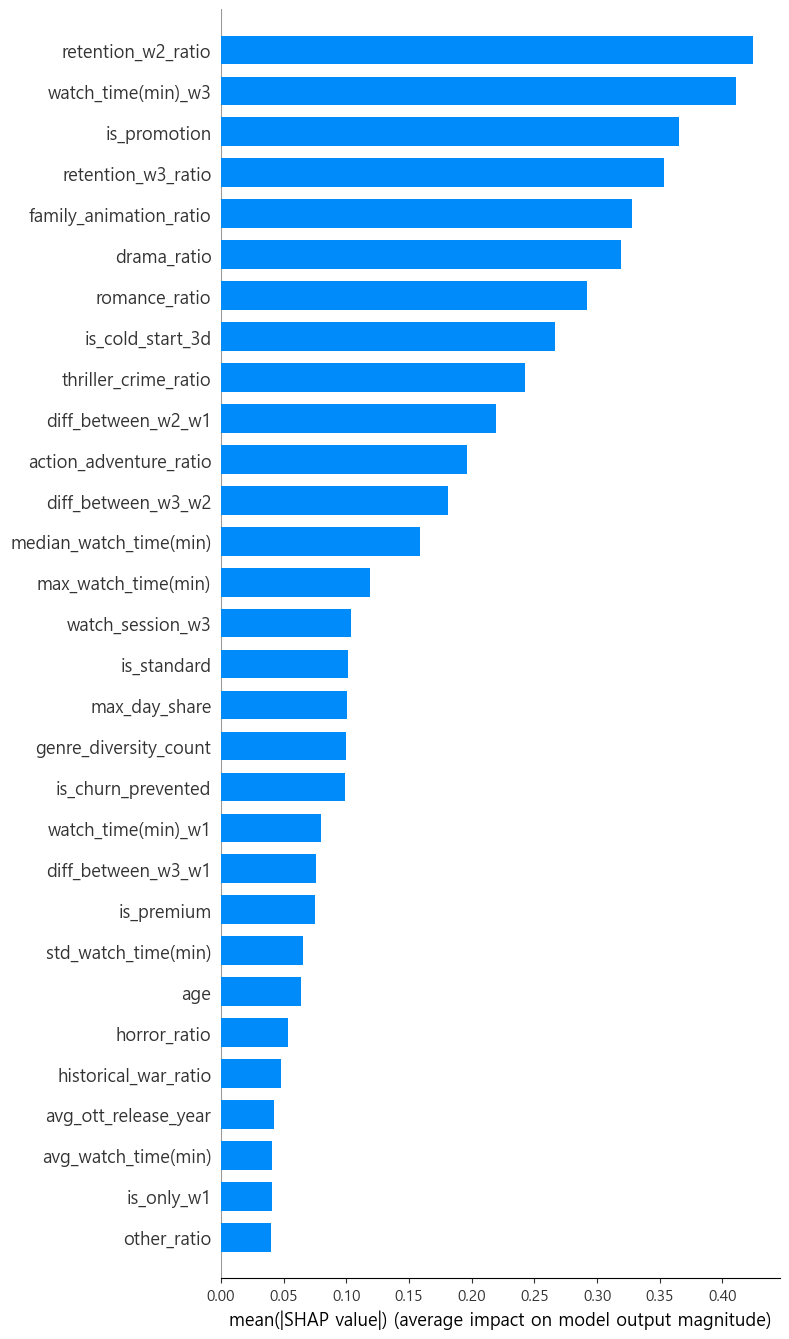

In [19]:
# =============================================================================
# 11. SHAP Summary Plot 저장: Bar
# =============================================================================

set_korean_font_if_available()

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_pos,
    X_shap,
    plot_type="bar",
    max_display=30,
    show=False,
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "lightgbm_shap_summary_bar.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close()


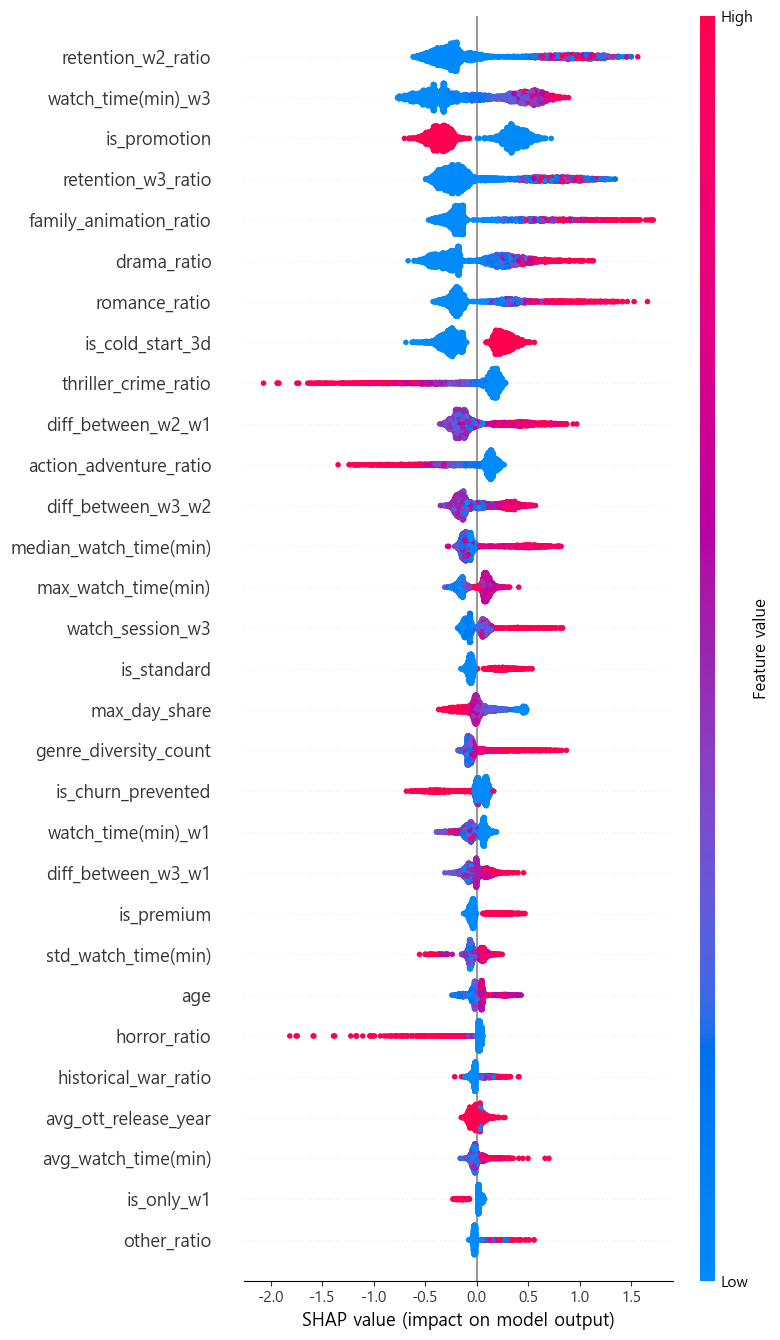

In [20]:
# =============================================================================
# 12. SHAP Summary Plot 저장: Beeswarm
# =============================================================================

set_korean_font_if_available()

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_pos,
    X_shap,
    max_display=30,
    show=False,
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "lightgbm_shap_summary_beeswarm.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close()


<Figure size 1000x600 with 0 Axes>

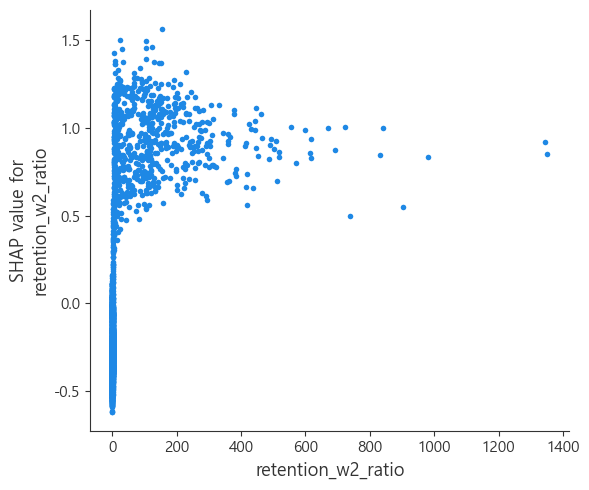

<Figure size 1000x600 with 0 Axes>

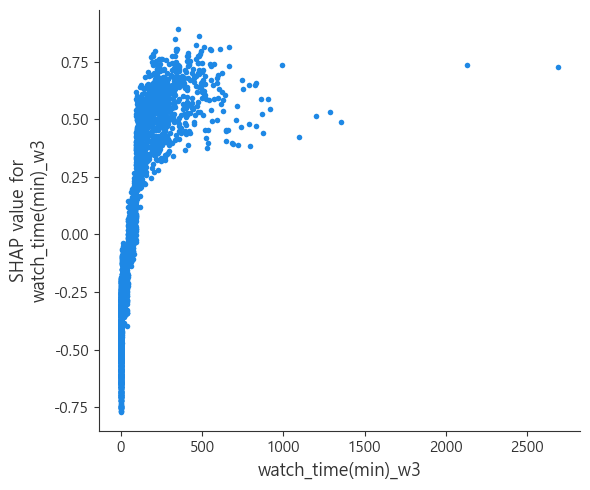

<Figure size 1000x600 with 0 Axes>

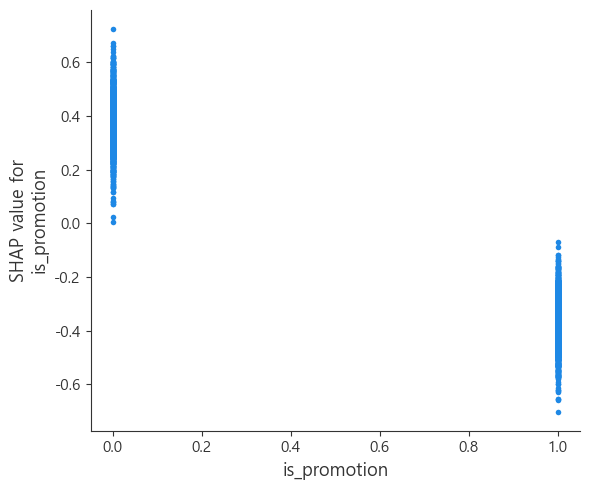

<Figure size 1000x600 with 0 Axes>

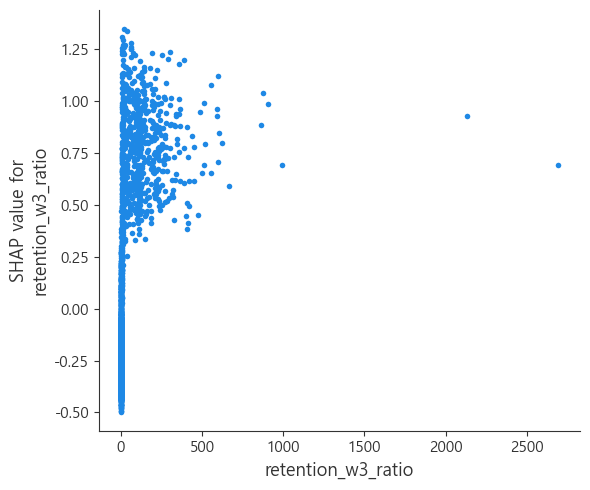

<Figure size 1000x600 with 0 Axes>

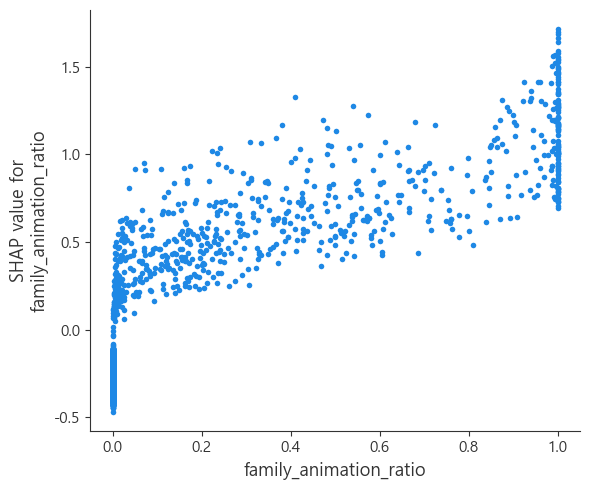

Dependence plot 저장 완료
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_shap_dependence_top1_retention_w2_ratio.png
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_shap_dependence_top2_watch_time(min)_w3.png
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_shap_dependence_top3_is_promotion.png
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_shap_dependence_top4_retention_w3_ratio.png
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_shap_dependence_top5_family_animation_ratio.png


In [21]:
# =============================================================================
# 13. 상위 변수 Dependence Plot 저장
# =============================================================================

set_korean_font_if_available()

TOP_N_DEPENDENCE = 5

top_features = shap_importance["feature"].head(TOP_N_DEPENDENCE).tolist()

dependence_files = []

for rank, feature in enumerate(top_features, start=1):
    safe_feature = sanitize_filename(feature)
    output_path = OUTPUT_DIR / f"lightgbm_shap_dependence_top{rank}_{safe_feature}.png"

    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        feature,
        shap_values_pos,
        X_shap,
        interaction_index=None,
        show=False,
    )
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    dependence_files.append(output_path)

print("=" * 80)
print("Dependence plot 저장 완료")
print("=" * 80)
for path in dependence_files:
    print(path)


In [22]:
# =============================================================================
# 14. LightGBM 기본 Feature Importance 저장
# =============================================================================

lgbm_importance = pd.DataFrame({
    "feature": X_train_t.columns,
    "lgbm_importance_gain": model.booster_.feature_importance(importance_type="gain"),
    "lgbm_importance_split": model.booster_.feature_importance(importance_type="split"),
})

lgbm_importance = lgbm_importance.sort_values(
    "lgbm_importance_gain",
    ascending=False,
).reset_index(drop=True)

lgbm_importance.to_csv(
    OUTPUT_DIR / "lightgbm_builtin_feature_importance.csv",
    index=False,
    encoding="utf-8-sig",
)

print("=" * 80)
print("Top 30 LightGBM Built-in Importance")
print("=" * 80)
print(lgbm_importance.head(30).to_string(index=False))

lgbm_importance.head(30)


Top 30 LightGBM Built-in Importance
                  feature  lgbm_importance_gain  lgbm_importance_split
       watch_time(min)_w3          36254.271402                    272
       retention_w2_ratio          15574.078457                    656
       diff_between_w2_w1          15123.364614                    402
              drama_ratio          11784.691042                    481
     thriller_crime_ratio          11012.145822                    540
   family_animation_ratio          10899.559028                    393
       retention_w3_ratio          10356.469064                    517
   action_adventure_ratio           9160.838661                    500
            romance_ratio           9104.182989                    372
         watch_session_w3           9000.794988                    115
       diff_between_w3_w2           8609.464811                    368
            max_day_share           6863.496979                    362
             is_promotion           6386.

,feature,lgbm_importance_gain,lgbm_importance_split
0,watch_time(min)_w3,36254.271402,272
1,retention_w2_ratio,15574.078457,656
2,diff_between_w2_w1,15123.364614,402
3,drama_ratio,11784.691042,481
4,thriller_crime_ratio,11012.145822,540
5,family_animation_ratio,10899.559028,393
6,retention_w3_ratio,10356.469064,517
7,action_adventure_ratio,9160.838661,500
8,romance_ratio,9104.182989,372
9,watch_session_w3,9000.794988,115


In [23]:
# =============================================================================
# 15. 저장 파일 목록 확인
# =============================================================================

saved_files = sorted(OUTPUT_DIR.glob("*"))

print("=" * 80)
print("Saved files")
print("=" * 80)
for path in saved_files:
    print(path)


Saved files
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_builtin_feature_importance.csv
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_shap_dependence_top1_retention_w2_ratio.png
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_shap_dependence_top2_watch_time(min)_w3.png
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_shap_dependence_top3_is_promotion.png
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_shap_dependence_top4_retention_w3_ratio.png
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_shap_dependence_top5_family_animation_ratio.png
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_shap_dropped_constant_columns.csv
C:\Code\ott-churn-prediction\park.ingyeom\reports\shap_outputs_260513\lightgbm_shap_dropped_explicit_columns.csv
C:\Code\ott-churn-prediction\park.ingye

## 해석 기준

`mean_abs_shap`는 해당 변수가 예측값을 얼마나 크게 흔들었는지의 평균 크기입니다.  
`mean_shap`가 양수이면 평균적으로 `is_repurchase = 1` 방향, 음수이면 평균적으로 `is_repurchase = 0` 방향으로 작용한 것입니다.  
다만 SHAP 값의 부호 해석은 반드시 beeswarm과 dependence plot에서 실제 변수값의 높고 낮음까지 같이 봐야 합니다.
